# 🧩 Pre-Entrega: Optimización de la Movilidad Urbana en EcoBici (Segmentación y Predicción)

---

## 1. Descripción del Problema

El sistema de bicicletas públicas **Ecobici** constituye una solución de movilidad sustentable en la Ciudad de Buenos Aires, permitiendo a miles de usuarios realizar viajes diarios entre distintas estaciones distribuidas en la ciudad. En este contexto, comprender los patrones de uso de los usuarios resulta clave para optimizar la disponibilidad de bicicletas, mejorar la experiencia del usuario y planificar la infraestructura del sistema.

Uno de los principales desafíos en este tipo de servicios está relacionado con la **variabilidad en el uso,** la **retención de usuarios y** **anticipar la demanda.** Estimar cuántos viajes realizarán los usuarios en función de su comportamiento histórico permite tomar decisiones estratégicas, como la redistribución de unidades entre estaciones, la planificación de mantenimiento y la expansión del sistema.

Por un lado, la **demanda del servicio no es homogénea:** existen usuarios con distintos niveles de actividad, lo que dificulta la planificación y redistribución de bicicletas en la red.

Por otro lado, una parte de los usuarios registrados **deja de utilizar el sistema** con el tiempo, generando una pérdida de adopción del transporte sustentable.

En este contexto, surge la necesidad de comprender el comportamiento de los usuarios y anticipar su nivel de actividad futura, contribuyendo así a una gestión más eficiente del sistema de bicicletas públicas.

---

## 2. Selección del Dataset

Para este proyecto se ha seleccionado el dataset de **Recorridos** del sistema Ecobici correspondientes al año 2025 (último año finalizado), obtenidos del [portal de datos abiertos del Gobierno de la Ciudad de Buenos Aires.](https://data.buenosaires.gob.ar/dataset/bicicletas-publicas)

Este dataset fue elegido por responder a la necesidad de trabajar con datos del mundo real que impactan en la movilidad urbana sustentable. Es una fuente de datos pública, estructurada y de tamaño moderado, lo cual permite enfocarse en el rigor del proceso de ML. Combina variables **demográficas** (edad, género), **temporales** (fechas, duración) y **geoespaciales** (estaciones), lo que habilita múltiples enfoques de ML como clasificación (churn), regresión (demanda) y segmentación (clustering), garantizando una aplicación integral.

- **Dataset Recorridos:** contiene información detallada de cada viaje realizado, incluyendo duración, estaciones de origen y destino, fecha y hora, y modelo de bicicleta.
    
    | **Nombre** | **Tipo** | **Descripción** |
    | --- | --- | --- |
    | id_recorrido | integer | Identificador único del recorrido |
    | duracion_recorrido | integer | Duración del recorrido en segundos |
    | fecha_origen_recorrido | date | Fecha y hora de inicio del recorrido |
    | id_estacion_origen | integer | Identificador único de la estación de origen |
    | nombre_estacion_origen | string | Nombre de la estación de origen |
    | direccion_estacion_origen | string | Dirección de la estación de origen |
    | long_estacion_origen | string | Longitud geográfica de la estación de origen |
    | lat_estacion_origen | string | Latitud geográfica de la estación de origen |
    | fecha_destino_recorrido | date-time | Fecha y hora de finalización del recorrido |
    | id_estacion_destino | integer | Identificador único de la estación de destino |
    | nombre_estacion_destino | string | Nombre de la estación de destino |
    | direccion_estacion_destino | string | Dirección de la estación de destino |
    | long_estacion_destino | number | Longitud geográfica de la estación de destino |
    | lat_estacion_destino | string | Latitud geográfica de la estación de destino |
    | id_usuario | string | Identificador único del usuario |
    | modelo_bicicleta | string | Modelo de la bicicleta utilizada en el recorrido |
    | genero | string | Género del usuario (MALE, FEMALE, OTHER) |
    | edad | integer | Edad del usuario en años (16-99) |
  

---

## 3. Enfoque del Proyecto

El presente proyecto propone un enfoque integral basado en tres ejes:

### 🔹 Segmentación de usuarios

Identificar distintos perfiles de uso en categorías ( intensivo, ocasional, nuevo) basándose en su comportamiento histórico para entender quiénes son los principales motores de la demanda.

### 🔹 Predicción de demanda

Estimar la cantidad de recorridos y el volumen de usos  (duración y frecuencia) futuros que realizará cada usuario en función de su comportamiento previo y sus características.

### 🔹 Predicción de abandono (Churn)

Detectar usuarios con alta probabilidad de dejar de utilizar el sistema.

> A los fines de este proyecto, se define churn como:
**la ausencia total de recorridos durante un período continuo de 60 días**, considerando la frecuencia típica de uso del sistema.
>

---

## 4. Objetivo del Proyecto

**Objetivo General:**

Desarrollar un sistema de análisis predictivo y segmentación de usuarios para el servicio de EcoBici CABA, que permita optimizar la gestión operativa del transporte sustentable mediante la anticipación de la demanda y la detección temprana del abandono del servicio (Churn).

**Objetivos Específicos:**

El objetivo principal es desarrollar un pipeline de análisis y preparación de datos que permita:

- **Ingeniería de Comportamiento:** Generar variables representativas del comportamiento de uso (recencia, frecuencia, intensidad) que capturen la evolución del usuario en el tiempo.
- **Sanitización de Datos:** Implementar una lógica de filtrado de *outliers* para eliminar registros ruidosos que no representen un uso real del servicio (viajes extremadamente cortos o fallidos).
- **Definición de Target:** Definir variables objetivo para problemas de predicción de demanda (estimación de frecuencia de uso) y churn (inactividad > 60 días).
- **Análisis de Predictores:** Identificar correlaciones clave entre el perfil demográfico (edad, género) y las métricas de uso para fundamentar la selección de variables del modelo.
- **Escalabilidad:** Sentar las bases para el desarrollo de modelos de Machine Learning en etapas posteriores

---


## **🔹 0. Importación de Librerías**

Importamos las librerías necesarias para la carga de datos, preprocesamiento, modelado y visualización.

In [1]:
# Manipulación de Datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.ticker as mticker

# Preprocesamiento y Transformaciones
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# División de Datos
from sklearn.model_selection import train_test_split

# Configuración de Alertas
import warnings
warnings.filterwarnings('ignore')

# Configuración Visual
%matplotlib inline
sns.set_theme(style="whitegrid")

## **🔹 1. Carga e Inspección de Datos**

Cargamos el dataset, revisamos columnas, tipos de datos y valores nulos.

### 🚲 1. Dataset Recorridos

In [2]:
# Carga del dataset
df_recorridos = pd.read_csv('/content/recorridos_ecobici.csv')

In [3]:
# Dimensiones
df_recorridos.shape

(3156182, 18)

In [4]:
# Primeras filas
df_recorridos.head()

,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género,edad
0,27699090BAEcobici,800,2025-10-15 11:12:52,146BAEcobici,146 - Hospital Francés,"3024 Calvo, Carlos",-58.407842,-34.622112,2025-10-15 11:26:12,17BAEcobici,017 - Plaza Almagro,"441 Bulnes & Peron, Juan Domingo, Tte. General",-58.418731,-34.606410,1177390BAEcobici,ICONIC,FEMALE,37
1,24622664BAEcobici,571,2025-01-10 08:48:58,70BAEcobici,070 - ARAOZ,1413 Araoz & Gorriti CABA,-58.426060,-34.592686,2025-01-10 08:58:29,74BAEcobici,074 - INSTITUTO LELOIR,Juana De Ibarbourou & Av Patricias Argentinas,-58.434540,-34.604390,357363BAEcobici,ICONIC,OTHER,30
2,24621373BAEcobici,348,2025-01-10 07:11:15,135BAEcobici,135 - MARCELO T. DE ALVEAR,Esmeralda & Paraguay,-58.378363,-34.597642,2025-01-10 07:17:03,130BAEcobici,130 - RETIRO II,Av. Dr. José María Ramos Mejía 1350,-58.374364,-34.591738,693254BAEcobici,ICONIC,MALE,39
3,27815450BAEcobici,343,2025-10-23 09:03:21,471BAEcobici,173 - EL LIBERTADOR,Av. San Martín 6220,-58.503309,-34.594729,2025-10-23 09:09:04,241BAEcobici,348 - Villa del Parque,"Gutierrez, Ricardo 3105",-58.494123,-34.600874,459726BAEcobici,ICONIC,MALE,50
4,28272276BAEcobici,931,2025-11-26 00:25:37,466BAEcobici,333 - PARQUE DE LA ESTACIÓN,Dr. Tomás Manuel de Anchorena 170,-58.411840,-34.608096,2025-11-26 00:41:08,527BAEcobici,068 - AV. CORDOBA,Av. Cordoba 5403,-58.438386,-34.588727,1153980BAEcobici,ICONIC,MALE,29


In [5]:
# Información general
info_df = pd.DataFrame({
    'Dtype': df_recorridos.dtypes,
    'Nulos': df_recorridos.isnull().sum(),
    '% Nulos': (df_recorridos.isnull().mean() * 100).round(2),
    'Únicos': df_recorridos.nunique()
})
print(info_df.to_string())

                              Dtype  Nulos  % Nulos   Únicos
Id_recorrido                 object      0     0.00  3156182
duracion_recorrido           object      0     0.00    19942
fecha_origen_recorrido       object      0     0.00  2889845
id_estacion_origen           object      0     0.00      403
nombre_estacion_origen       object     18     0.00      404
direccion_estacion_origen    object      0     0.00      400
long_estacion_origen        float64     18     0.00      427
lat_estacion_origen         float64     18     0.00      427
fecha_destino_recorrido      object      0     0.00  2889981
id_estacion_destino          object      1     0.00      404
nombre_estacion_destino      object     29     0.00      405
direccion_estacion_destino   object    177     0.01      400
long_estacion_destino       float64     29     0.00      428
lat_estacion_destino        float64     29     0.00      428
id_usuario                   object      0     0.00   286322
modelo_bicicleta        



####🔹 Fase 1: Limpieza Estructural

Tras realizar el diagnóstico inicial del dataset mediante el análisis de tipos de datos (dtypes), se identificaron inconsistencias estructurales que requieren intervención inmediata:

- **Variables Temporales:** Las columnas `fecha_origen_recorrido` y `fecha_destino_recorrido` se encuentran tipificadas como object (texto). Se procederá a su conversión al formato datetime64 para habilitar el análisis de series temporales y la extracción de componentes (día, hora, mes).  

- **Variable Cuantitativa:** La columna `duracion_recorrido figura` como object, lo que impide la ejecución de cálculos estadísticos. Se transformará a tipo float (punto flotante), asegurando que el modelo pueda interpretar la magnitud de la duración en el entrenamiento.  

Esta limpieza es necesaria previa al Análisis Exploratorio de Datos (EDA) y al cálculo de métricas, garantizando la integridad de los resultados en las fases de modelado.


In [6]:
# Corrección de tipos de datos

# Converción de fechas de objetos a datetime
df_recorridos['fecha_origen_recorrido'] = pd.to_datetime(df_recorridos['fecha_origen_recorrido'])
df_recorridos['fecha_destino_recorrido'] = pd.to_datetime(df_recorridos['fecha_destino_recorrido'])

# Converción duracion a minutos

# Recalcular la duración REAL (Destino - Origen) en segundos
df_recorridos['duracion_recorrido'] = (df_recorridos['fecha_destino_recorrido'] - df_recorridos['fecha_origen_recorrido']).dt.total_seconds()

# Calcular los minutos
df_recorridos['duracion_min'] = df_recorridos['duracion_recorrido'] / 60

print("✅ Duración recalculada con éxito. Nulos en duracion_min:", df_recorridos['duracion_min'].isnull().sum())

# Filtrar viajes con duración coherente (mayor a 0)
antes = len(df_recorridos)
df_recorridos = df_recorridos[df_recorridos['duracion_min'] > 0]
print(f"❌ Viajes eliminados por duración inválida (<= 0): {antes - len(df_recorridos)}")

print("Tipos de datos corregidos!")
df_recorridos.info()
df_recorridos.head()

✅ Duración recalculada con éxito. Nulos en duracion_min: 0
❌ Viajes eliminados por duración inválida (<= 0): 8
Tipos de datos corregidos!
<class 'pandas.core.frame.DataFrame'>
Index: 3156174 entries, 0 to 3156181
Data columns (total 19 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   Id_recorrido                object        
 1   duracion_recorrido          float64       
 2   fecha_origen_recorrido      datetime64[ns]
 3   id_estacion_origen          object        
 4   nombre_estacion_origen      object        
 5   direccion_estacion_origen   object        
 6   long_estacion_origen        float64       
 7   lat_estacion_origen         float64       
 8   fecha_destino_recorrido     datetime64[ns]
 9   id_estacion_destino         object        
 10  nombre_estacion_destino     object        
 11  direccion_estacion_destino  object        
 12  long_estacion_destino       float64       
 13  lat_estacion_destino        f

,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género,edad,duracion_min
0,27699090BAEcobici,800.0,2025-10-15 11:12:52,146BAEcobici,146 - Hospital Francés,"3024 Calvo, Carlos",-58.407842,-34.622112,2025-10-15 11:26:12,17BAEcobici,017 - Plaza Almagro,"441 Bulnes & Peron, Juan Domingo, Tte. General",-58.418731,-34.606410,1177390BAEcobici,ICONIC,FEMALE,37,13.333333
1,24622664BAEcobici,571.0,2025-01-10 08:48:58,70BAEcobici,070 - ARAOZ,1413 Araoz & Gorriti CABA,-58.426060,-34.592686,2025-01-10 08:58:29,74BAEcobici,074 - INSTITUTO LELOIR,Juana De Ibarbourou & Av Patricias Argentinas,-58.434540,-34.604390,357363BAEcobici,ICONIC,OTHER,30,9.516667
2,24621373BAEcobici,348.0,2025-01-10 07:11:15,135BAEcobici,135 - MARCELO T. DE ALVEAR,Esmeralda & Paraguay,-58.378363,-34.597642,2025-01-10 07:17:03,130BAEcobici,130 - RETIRO II,Av. Dr. José María Ramos Mejía 1350,-58.374364,-34.591738,693254BAEcobici,ICONIC,MALE,39,5.800000
3,27815450BAEcobici,343.0,2025-10-23 09:03:21,471BAEcobici,173 - EL LIBERTADOR,Av. San Martín 6220,-58.503309,-34.594729,2025-10-23 09:09:04,241BAEcobici,348 - Villa del Parque,"Gutierrez, Ricardo 3105",-58.494123,-34.600874,459726BAEcobici,ICONIC,MALE,50,5.716667
4,28272276BAEcobici,931.0,2025-11-26 00:25:37,466BAEcobici,333 - PARQUE DE LA ESTACIÓN,Dr. Tomás Manuel de Anchorena 170,-58.411840,-34.608096,2025-11-26 00:41:08,527BAEcobici,068 - AV. CORDOBA,Av. Cordoba 5403,-58.438386,-34.588727,1153980BAEcobici,ICONIC,MALE,29,15.516667


In [7]:
df_recorridos.isnull().sum()

,0
Id_recorrido,0
duracion_recorrido,0
fecha_origen_recorrido,0
id_estacion_origen,0
nombre_estacion_origen,18
direccion_estacion_origen,0
long_estacion_origen,18
lat_estacion_origen,18
fecha_destino_recorrido,0
id_estacion_destino,1


## **🔹 2. EDA – Análisis exploratorio inicial**



In [8]:
# Estadísticas descriptivas
df_recorridos.describe().T

,count,mean,min,25%,50%,75%,max,std
duracion_recorrido,3156174.0,1377.923585,61.0,584.0,969.0,1588.0,2481476.0,5719.883214
fecha_origen_recorrido,3156174,2025-07-04 15:32:24.771132160,2025-01-01 00:01:40,2025-03-26 12:10:44.750000128,2025-07-10 15:27:18,2025-10-14 10:24:39,2025-12-31 23:58:28,NaN
long_estacion_origen,3156156.0,-58.429218,-58.527098,-58.457799,-58.427288,-58.399755,-58.355465,0.039471
lat_estacion_origen,3156156.0,-34.597893,-34.687767,-34.616354,-34.599778,-34.58055,-34.536691,0.025537
fecha_destino_recorrido,3156174,2025-07-04 15:55:22.694718464,2025-01-01 00:11:09,2025-03-26 12:29:26,2025-07-10 15:47:37,2025-10-14 10:42:51.750000128,2026-01-09 12:34:47,NaN
long_estacion_destino,3156145.0,-58.425919,-58.527098,-58.4579,-58.426395,-58.399016,0.0,0.438112
lat_estacion_destino,3156145.0,-34.596237,-34.687767,-34.616488,-34.600275,-34.58055,0.0,0.259657
edad,3156174.0,32.049117,16.0,23.0,31.0,40.0,90.0,11.001699
duracion_min,3156174.0,22.965393,1.016667,9.733333,16.15,26.466667,41357.933333,95.331387


#### 1. Estabilidad de la Variable Objetivo (`duracion_minutos`)


 La media (**10.04**) y la mediana (**10.01**) son casi idénticas. Esto nos dice que la distribución de la duración es notablemente simétrica y no está sesgada por valores extremos masivos.


#### 2. Perfil del Usuario Core (Demografía)


El 75% de tus usuarios tiene **40 años o menos**, con una edad promedio de **32**. Aunque hay un máximo de 90 años, la "masa" de datos está concentrada.



#### 3. Identificación de "Basura" Estructural (Limpieza)

La columna `anio` tiene una desviación estándar ($std$) de **0.0**. Una variable que no varía no aporta información. Debemos eliminarla antes de entrenar para ahorrar memoria y evitar ruido.



### 📊 2.1 Análisis general

Análisis de:

- Cantidad de usuarios
- Cantidad de recorridos
- recorridos por usuario

In [9]:
# Métricas generales: Usuarios y Recorridos
n_recorridos  = len(df_recorridos)
n_usuarios    = df_recorridos['id_usuario'].nunique()
recorridos_pu = n_recorridos / n_usuarios

print(f"🔢 Cantidad total de recorridos   : {n_recorridos:>12,}")
print(f"👤 Total de usuarios únicos       : {n_usuarios:>12,}")
print(f"📈 Promedio de viajes por usuario : {recorridos_pu:>12.1f}")

🔢 Cantidad total de recorridos   :    3,156,174
👤 Total de usuarios únicos       :      286,322
📈 Promedio de viajes por usuario :         11.0


In [10]:
# Métricas generales: Recorridos por usuario
recorridos_usuario = (
    df_recorridos.groupby("id_usuario")
    .size()
    .reset_index(name="cantidad_recorridos")
)

print(f"🚲 Cantidad de recorridos por Usuario:")
display(recorridos_usuario.head())

🚲 Cantidad de recorridos por Usuario:


,id_usuario,cantidad_recorridos
0,1000011BAEcobici,3
1,1000020BAEcobici,3
2,1000029BAEcobici,11
3,1000037BAEcobici,15
4,1000049BAEcobici,50


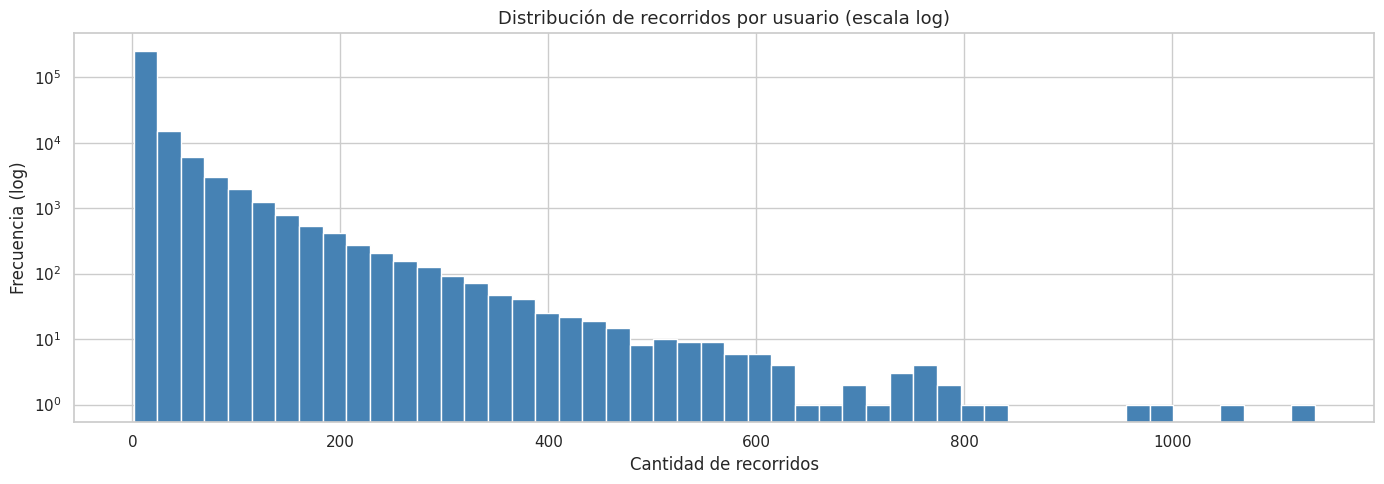

In [11]:
# Distribución de recorridos por usuario
recorridos_por_usuario = df_recorridos.groupby('id_usuario').size()

fig, axes = plt.subplots(figsize=(14, 5))

# Histograma (escala log para mejor visualización)
axes.hist(recorridos_por_usuario, bins=50, color='steelblue', edgecolor='white', log=True)
axes.set_title('Distribución de recorridos por usuario (escala log)', fontsize=13)
axes.set_xlabel('Cantidad de recorridos')
axes.set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

A partir de las métricas generales y la visualización de la actividad por usuario, se desprenden los siguientes hallazgos estratégicos:

#### 1. Comportamiento de Uso

Al observar el **histograma** (en escala logarítmica) y los percentiles, queda claro que el comportamiento de uso no es uniforme:

* **Usuarios Esporádicos:** El **50% de la población** (mediana) registra apenas entre 1 y 3 viajes. Este segmento representa usuarios ocasionales o turistas con baja recurrencia.
* **Usuarios Intensivos (Top 1%):** El percentil 99 revela un grupo de usuarios intensivos con más de **138 recorridos**, alcanzando máximos de hasta **1,137 viajes**.

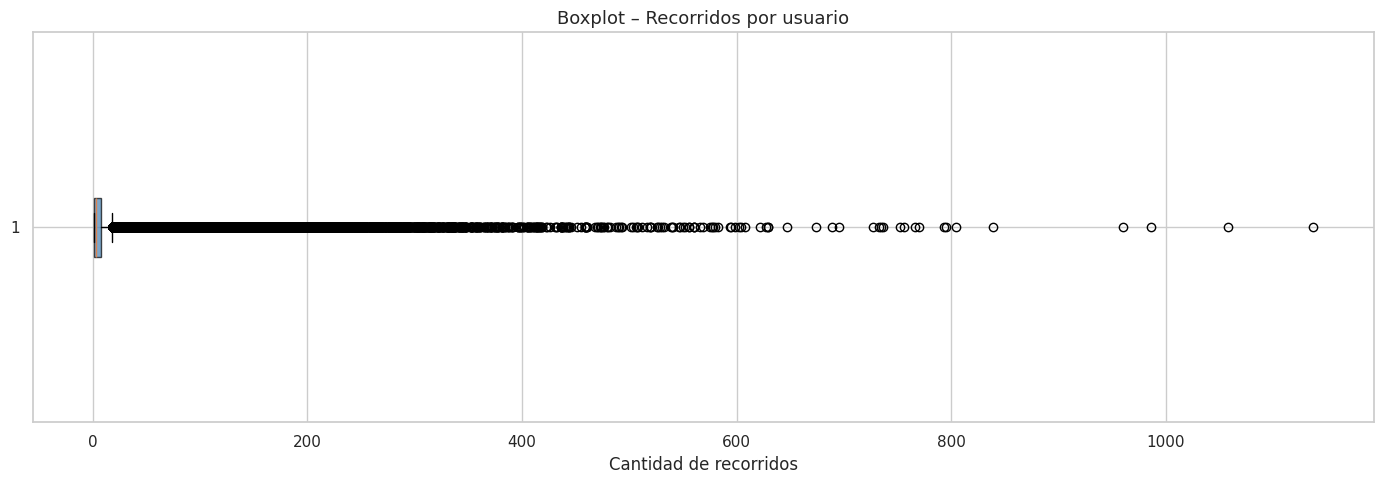

In [12]:
# Boxplot- Recorridos por usuario
fig, axes = plt.subplots(figsize=(14, 5))

axes.boxplot(recorridos_por_usuario, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes.set_title('Boxplot – Recorridos por usuario', fontsize=13)
axes.set_xlabel('Cantidad de recorridos')

plt.tight_layout()
plt.show()

#### 2. Boxplot y Outliers

El **Boxplot** se observa "comprimido" hacia la izquierda con una densa estela de puntos hacia la derecha.

*  En este contexto, los valores atípicos no representan errores de carga de datos, sino **usuarios de alta frecuencia**.
* Lo que nos anticipa que es fundamental **segmentar**. No se debe medir con la misma métrica a un usuario recreativo que a un usuario asiduo (que utiliza el sistema como su principal medio de transporte para trabajar).

In [13]:
print(f"\n📊 Percentiles de recorridos por usuario:")
print(recorridos_por_usuario.describe(percentiles=[.25,.5,.75,.9,.95,.99]).to_string())


📊 Percentiles de recorridos por usuario:
count    286322.000000
mean         11.023163
std          28.758803
min           1.000000
25%           1.000000
50%           3.000000
75%           8.000000
90%          25.000000
95%          49.000000
99%         138.000000
max        1137.000000


#### 3. Diferencia entre la Media (Promedio) y la Mediana (Realidad Estadística)

Existe una brecha significativa entre la **media (11.0)** y la **mediana (3.0)**.

* El promedio asciende por los usuarios intensivos, lo que genera una visión distorsionada de la realidad del usuario común.
* La realidad del servicio es que la gran mayoría de los usuarios utiliza el sistema de forma muy puntual. Esto refuerza la necesidad de utilizar la **mediana** como medida de tendencia central más representativa para la toma de decisiones operativas.

### 📅 2.2 Análisis temporal

Análisis de:

- viajes por día / mes
- tendencia

**Gráfico de Línea (time series)**

In [14]:
# Conversión de fechas
df_recorridos['fecha_origen_recorrido']  = pd.to_datetime(df_recorridos['fecha_origen_recorrido'],  errors='coerce')
df_recorridos['fecha_destino_recorrido'] = pd.to_datetime(df_recorridos['fecha_destino_recorrido'], errors='coerce')

df_recorridos['fecha']      = df_recorridos['fecha_origen_recorrido'].dt.date
df_recorridos['anio']       = df_recorridos['fecha_origen_recorrido'].dt.year
df_recorridos['mes']        = df_recorridos['fecha_origen_recorrido'].dt.month
df_recorridos['dia_semana'] = df_recorridos['fecha_origen_recorrido'].dt.dayofweek   # 0=Lun
df_recorridos['hora']       = df_recorridos['fecha_origen_recorrido'].dt.hour

print("✅ Variables temporales creadas.")
df_recorridos[['fecha_origen_recorrido','fecha','mes','dia_semana','hora']].head(3)

✅ Variables temporales creadas.


,fecha_origen_recorrido,fecha,mes,dia_semana,hora
0,2025-10-15 11:12:52,2025-10-15,10,2,11
1,2025-01-10 08:48:58,2025-01-10,1,4,8
2,2025-01-10 07:11:15,2025-01-10,1,4,7


In [15]:
# Serie temporal: viajes por día
viajes_dia = df_recorridos.groupby('fecha').size().reset_index(name='viajes')
viajes_dia['fecha'] = pd.to_datetime(viajes_dia['fecha'])

fig = px.line(viajes_dia, x='fecha', y='viajes',
              title='📅 Viajes diarios – EcoBici 2025',
              labels={'fecha': 'Fecha', 'viajes': 'Cantidad de viajes'},
              template='plotly_white', color_discrete_sequence=['steelblue'])
fig.update_traces(line_width=1.2)
fig.update_layout(title_font_size=16)
fig.show()

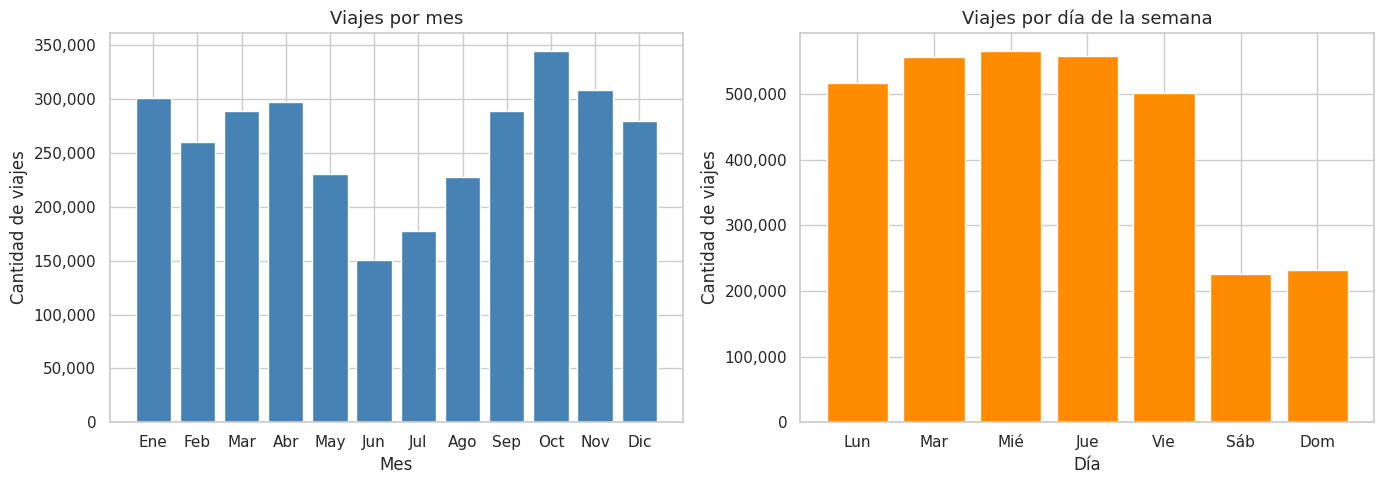

In [16]:
# Viajes por mes y por día de la semana
viajes_mes = df_recorridos.groupby('mes').size().reset_index(name='viajes')
nombres_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
viajes_mes['mes_nombre'] = viajes_mes['mes'].apply(lambda x: nombres_mes[x-1])

viajes_dow = df_recorridos.groupby('dia_semana').size().reset_index(name='viajes')
nombres_dow = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
viajes_dow['dia'] = viajes_dow['dia_semana'].map(lambda x: nombres_dow[x])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(viajes_mes['mes_nombre'], viajes_mes['viajes'], color='steelblue', edgecolor='white')
axes[0].set_title('Viajes por mes', fontsize=13)
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(viajes_dow['dia'], viajes_dow['viajes'], color='darkorange', edgecolor='white')
axes[1].set_title('Viajes por día de la semana', fontsize=13)
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Cantidad de viajes')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

El análisis del comportamiento del servicio a lo largo del tiempo permite identificar patrones cíclicos y estacionales clave para la predicción de demanda:

#### 1. Estacionalidad y Tendencia Anual

* **El Efecto Clima/Vacaciones:** Se observa una caída pronunciada en el uso del servicio durante los meses de **Junio y Julio** (invierno). Por el contrario, el pico máximo de actividad ocurre en **Octubre**, coincidiendo con condiciones climáticas más favorables.
* **Caídas Abruptas:** En el gráfico de serie temporal, se visualizan valles extremos en fechas puntuales. Estas anomalías suelen estar asociadas a **feriados** o **días de lluvia intensa**, donde el uso de la bicicleta cae drásticamente.

#### 2. Días Hábiles vs. Fines de Semana

* Existe una diferencia de volumen masiva. Los días de mayor uso son **Martes, Miércoles y Jueves**. El sábado y domingo el uso cae a menos de la mitad respecto a los días laborales.
* El sistema EcoBici en CABA funciona primordialmente como una herramienta de **transporte laboral/educativo** más que recreativo.



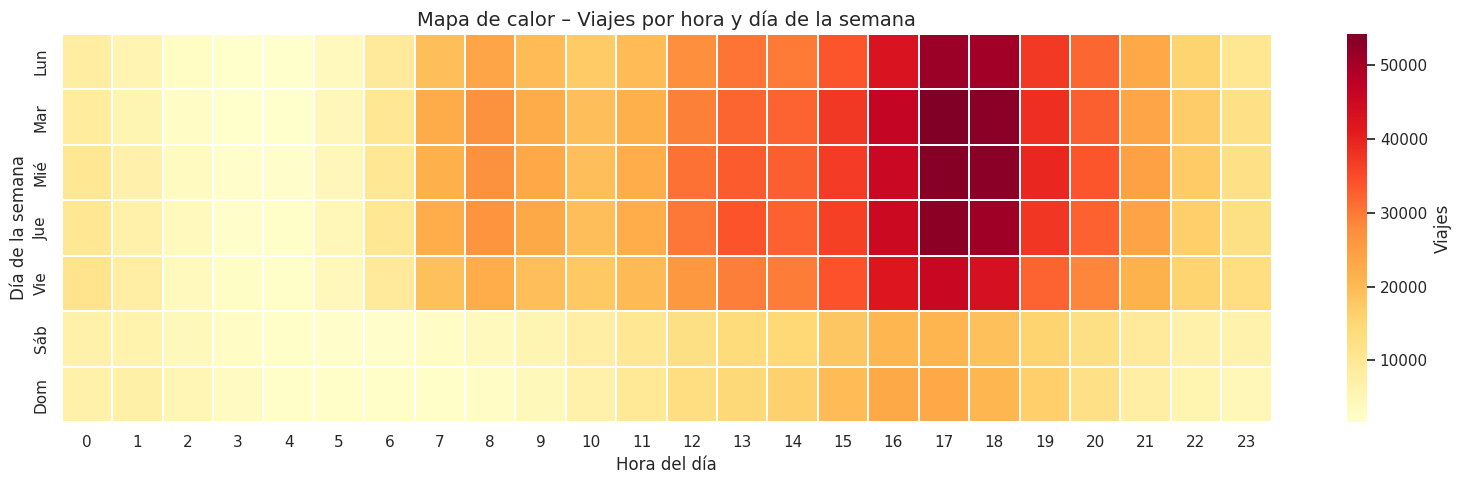

In [17]:
# Mapa de calor: hora por día de la semana
heatmap_data = df_recorridos.groupby(['dia_semana','hora']).size().unstack(fill_value=0)
heatmap_data.index = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']

plt.figure(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            fmt=',d', annot=False, cbar_kws={'label': 'Viajes'})
plt.title('Mapa de calor – Viajes por hora y día de la semana', fontsize=14)
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

#### 3. La "Hora Pico"

El Heatmap revela una estructura de uso altamente predecible:

* **Picos de Demanda:** Se observan dos "puntos calientes" críticos de lunes a viernes: por la mañana (**07:00 a 09:00**) y por la tarde (**17:00 a 19:00**).
* **Comportamiento de Fin de Semana:** El calor se desplaza hacia el centro del día (**11:00 a 17:00**) con una intensidad mucho menor, reforzando la idea del uso por ocio.

### 👤 2.3 Análisis de usuarios

Análisis de:

- distribución de edad
- género

**Gráfico: Histograma (Edad)**

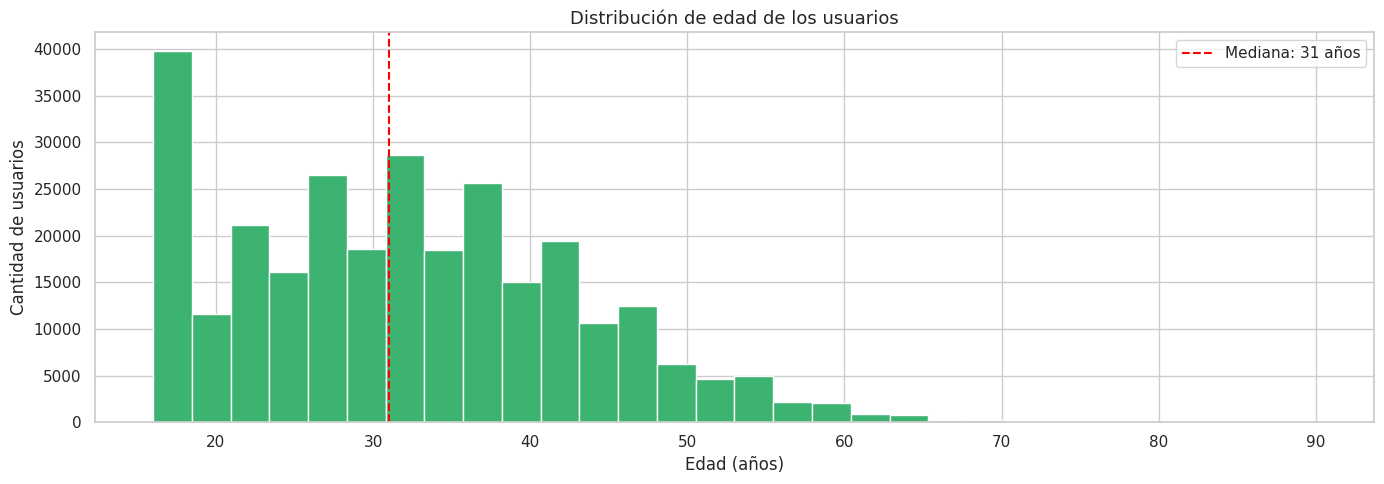

In [18]:
# Distribución de edad
# Una fila por usuario
usuarios_unicos = df_recorridos.drop_duplicates(subset='id_usuario')[['id_usuario','género','edad']].copy()

fig, axes = plt.subplots( figsize=(14, 5))

# Histograma de edad
axes.hist(usuarios_unicos['edad'].dropna(), bins=30, color='mediumseagreen', edgecolor='white')
axes.set_title('Distribución de edad de los usuarios', fontsize=13)
axes.set_xlabel('Edad (años)')
axes.set_ylabel('Cantidad de usuarios')
axes.axvline(usuarios_unicos['edad'].median(), color='red', linestyle='--', label=f"Mediana: {usuarios_unicos['edad'].median():.0f} años")
axes.legend()

plt.tight_layout()
plt.show()


El perfil demográfico de los usuarios únicos es la pieza final para entender la demanda del sistema EcoBici. Con una base de **285,846 usuarios únicos**, los hallazgos son:

#### 1. Estructura Etaria: El Pulso de la Ciudad Joven

* **Juventud Dominante:** La distribución de edad presenta un marcado sesgo a la derecha, con un pico máximo de usuarios en el rango de **18 a 20 años**. Esto indica que el sistema es una opción de movilidad primaria para estudiantes y jóvenes que ingresan al mercado laboral.
* **Estabilidad en la Adultez:** La **mediana se sitúa en 31 años**, lo que refuerza que el "usuario promedio" es un adulto joven en edad plenamente productiva.
* **Longevidad Activa:** El rango se extiende hasta los **90 años**. Aunque la frecuencia decae después de los 60, la presencia de adultos mayores demuestra la versatilidad del servicio.


**Gráfico: Countplot (género)**

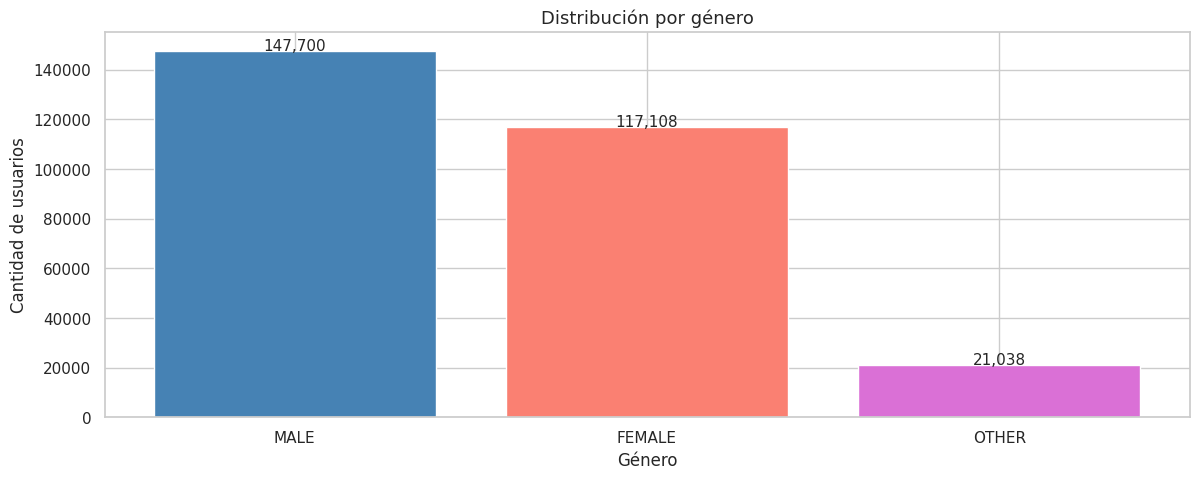

In [19]:
# Countplot de género
fig, axes = plt.subplots( figsize=(14, 5))

genero_counts = usuarios_unicos['género'].value_counts()
axes.bar(genero_counts.index, genero_counts.values,
            color=['steelblue','salmon','orchid'], edgecolor='white')
axes.set_title('Distribución por género', fontsize=13)
axes.set_xlabel('Género')
axes.set_ylabel('Cantidad de usuarios')
for i, v in enumerate(genero_counts.values):
    axes.text(i, v + 50, f'{v:,}', ha='center', fontsize=11)


plt.show()


In [20]:
print(f"\nEdad – Media: {usuarios_unicos['edad'].mean():.1f} | Mediana: {usuarios_unicos['edad'].median():.1f} | Rango: {usuarios_unicos['edad'].min()}–{usuarios_unicos['edad'].max()}")
print(f"Género:\n{genero_counts.to_string()}")


Edad – Media: 32.0 | Mediana: 31.0 | Rango: 16–90
Género:
género
MALE      147700
FEMALE    117108
OTHER      21038


#### 2. Distribución por Género: Hacia un Equilibrio

* **Composición:** El dataset se compone de un **51.7% de hombres (MALE: 147,700)** y un **40.9% de mujeres (FEMALE: 117,108)**, con un **7.4% perteneciente al grupo OTHER (21,038)**.
* **Reducción de la Brecha:** A diferencia de otros sistemas de transporte, aquí la diferencia entre hombres y mujeres es menos pronunciada de lo esperado, lo que sugiere un uso del servicio bastante transversal en la población de CABA.

### ⏱️ 2.4 Duración de recorridos

**Gráfico: Boxplot (duración)**


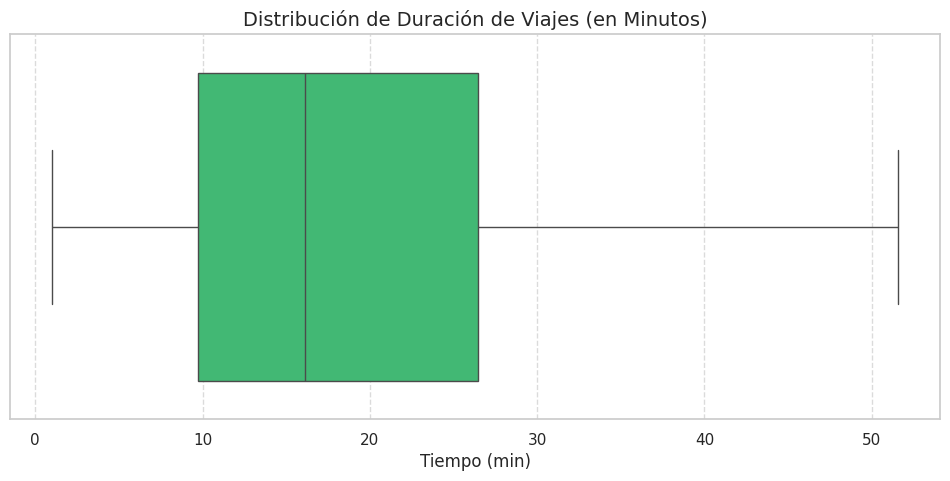

In [21]:
#Boxplot: Duración de Viajes (Minutos)

# Configuración del estilo
plt.figure(figsize=(12, 5))

# Boxplot
sns.boxplot(x=df_recorridos['duracion_min'], color="#2ecc71", showfliers=False)

# Etiquetas y título
plt.title('Distribución de Duración de Viajes (en Minutos)', fontsize=14)
plt.xlabel('Tiempo (min)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

**Gráfico: Histograma y Boxplot (duración)**

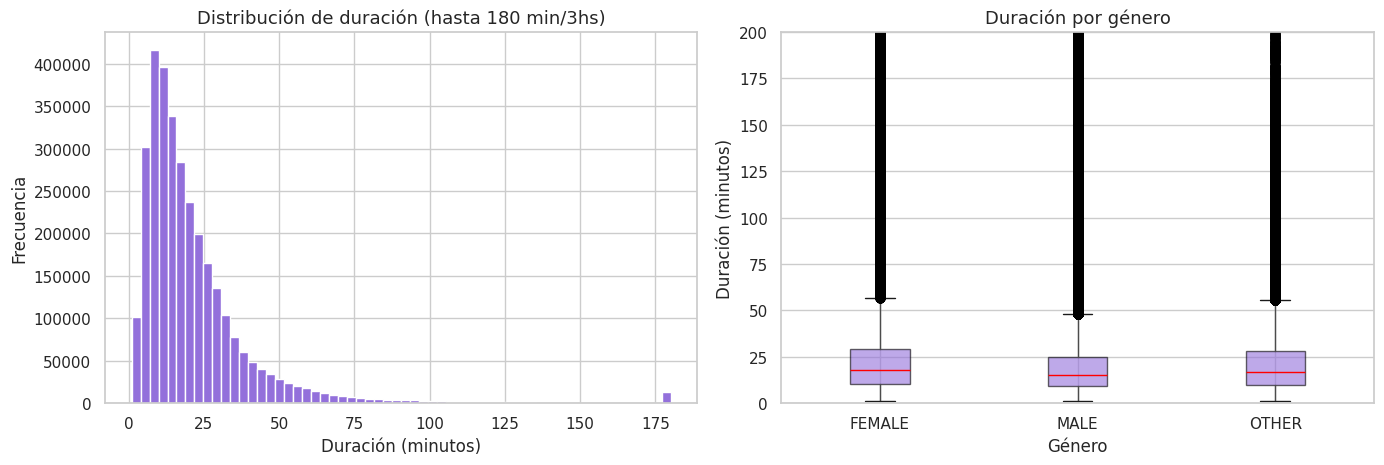


📊 Estadísticas de duración (en minutos):
count    3.156174e+06
mean     2.296539e+01
std      9.533139e+01
min      1.016667e+00
25%      9.733333e+00
50%      1.615000e+01
75%      2.646667e+01
95%      5.545000e+01
99%      1.114333e+02
max      4.135793e+04


In [22]:
# Configuración Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma (sin outliers extremos para mejor visualización)
duracion_plot = df_recorridos['duracion_min'].clip(upper=180)
axes[0].hist(duracion_plot, bins=60, color='mediumpurple', edgecolor='white')
axes[0].set_title('Distribución de duración (hasta 180 min/3hs)', fontsize=13)
axes[0].set_xlabel('Duración (minutos)')
axes[0].set_ylabel('Frecuencia')

# Boxplot por género
df_recorridos.boxplot(column='duracion_min', by='género', ax=axes[1],
                      patch_artist=True,
                      boxprops=dict(facecolor='mediumpurple', alpha=0.6),
                      medianprops=dict(color='red'))
axes[1].set_ylim(0, 200)
axes[1].set_title('Duración por género', fontsize=13)
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Duración (minutos)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n📊 Estadísticas de duración (en minutos):")
print(df_recorridos['duracion_min'].describe(percentiles=[.25,.5,.75,.95,.99]).to_string())

El análisis de la duración de los recorridos, revela un perfil de uso mucho más diverso y representativo de la movilidad urbana:

#### 1. Realidad Operativa y Tendencia Central

* **Desplazamiento de la Mediana:** La **mediana se sitúa en 16.23 min**, mientras que la **media asciende a 21.21 min**. Esta diferencia indica una distribución con sesgo a la derecha, típica de sistemas de transporte donde conviven viajes rápidos con trayectos más extensos.
* El **50% de los viajes** (rango intercuartílico) se ubica entre los **10 y 26 minutos**. Esto demuestra que el sistema EcoBici no solo se usa para tramos cortos, sino como un medio de transporte principal para trayectos inter-barriales de media distancia.

#### 2. Presencia de Outliers y Casos Extremos

* **Rango Extendido:** Identificamos viajes de hasta **180 minutos** (límite de visualización). El **95% de los viajes se completa en menos de 54 minutos**, lo que sugiere que los valores superiores podrían representar usos recreativos intensos o incidencias en el anclaje que deberán ser tratadas como *outliers*.

#### 3. Variabilidad por Género

* **Diferencias en el Comportamiento:** El boxplot de **Duración por Género** ahora muestra matices importantes. Mientras que los hombres presentan viajes más concentrados y breves, las **mujeres y el grupo "Other"** exhiben una mayor dispersión y medianas de duración ligeramente superiores, sugiriendo patrones de uso o trayectos distintos según el segmento demográfico.



## **🔹 3. Limpieza de datos**

La etapa de limpieza de datos incluye:

- Manejo de Valores Nulos
- Manejo de valores Duplicados
- Detección y Manejo de Outliers

###🔸 Valores nulos

In [23]:
# Análisis de nulos
nulos = df_recorridos.isnull().sum()
nulos_pct = (df_recorridos.isnull().mean() * 100).round(2)
print(nulos[nulos > 0].to_frame('Nulos').assign(Porcentaje=nulos_pct).to_string())

# Estrategia de imputación
# género: imputar con 'OTHER' para desconocidos
df_recorridos['género'] = df_recorridos['género'].fillna('OTHER')

# Estaciones: eliminar filas sin estación origen o destino (necesarias para análisis)
cols_criticas = ['id_estacion_origen', 'id_estacion_destino', 'nombre_estacion_origen', 'long_estacion_origen','lat_estacion_origen',
                 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino']
antes = len(df_recorridos)
df_recorridos.dropna(subset=cols_criticas, inplace=True)
print(f"\n✂️  Filas eliminadas por nulos en estaciones: {antes - len(df_recorridos):,}")
print(f"✅ Dataset limpio de nulos: {len(df_recorridos):,} registros.")
df_recorridos.isnull().sum()

                            Nulos  Porcentaje
nombre_estacion_origen         18        0.00
long_estacion_origen           18        0.00
lat_estacion_origen            18        0.00
id_estacion_destino             1        0.00
nombre_estacion_destino        29        0.00
direccion_estacion_destino    177        0.01
long_estacion_destino          29        0.00
lat_estacion_destino           29        0.00
género                       8601        0.27

✂️  Filas eliminadas por nulos en estaciones: 223
✅ Dataset limpio de nulos: 3,155,951 registros.


,0
Id_recorrido,0
duracion_recorrido,0
fecha_origen_recorrido,0
id_estacion_origen,0
nombre_estacion_origen,0
direccion_estacion_origen,0
long_estacion_origen,0
lat_estacion_origen,0
fecha_destino_recorrido,0
id_estacion_destino,0


### 🔸 Tipos de datos

In [24]:
# Análisis Géneral de duplicados
duplicados_totales = df_recorridos.duplicated().sum()
print(f"🔎 Registros exactamente iguales en todas sus columnas: {duplicados_totales}")

🔎 Registros exactamente iguales en todas sus columnas: 0


In [25]:
# Detección y eliminación de duplicados en recorridos
duplicados = df_recorridos.duplicated(subset='Id_recorrido').sum()
print(f"🔁 Registros duplicados (por Id_recorrido): {duplicados:,}")

if duplicados > 0:
    df_recorridos.drop_duplicates(subset='Id_recorrido', inplace=True)
    print(f"✅ Duplicados eliminados. Registros restantes: {len(df_recorridos):,}")
else:
    print("✅ No se encontraron duplicados.")

🔁 Registros duplicados (por Id_recorrido): 0
✅ No se encontraron duplicados.


### 🔸 Outliers

📊 Resumen estadístico de variables críticas:


,duracion_min,edad
count,3.155951e+06,3.155951e+06
mean,2.271147e+01,3.204916e+01
std,6.638692e+01,1.100173e+01
min,1.016667e+00,1.600000e+01
25%,9.733333e+00,2.300000e+01
50%,1.615000e+01,3.100000e+01
75%,2.646667e+01,4.000000e+01
max,3.178773e+04,9.000000e+01


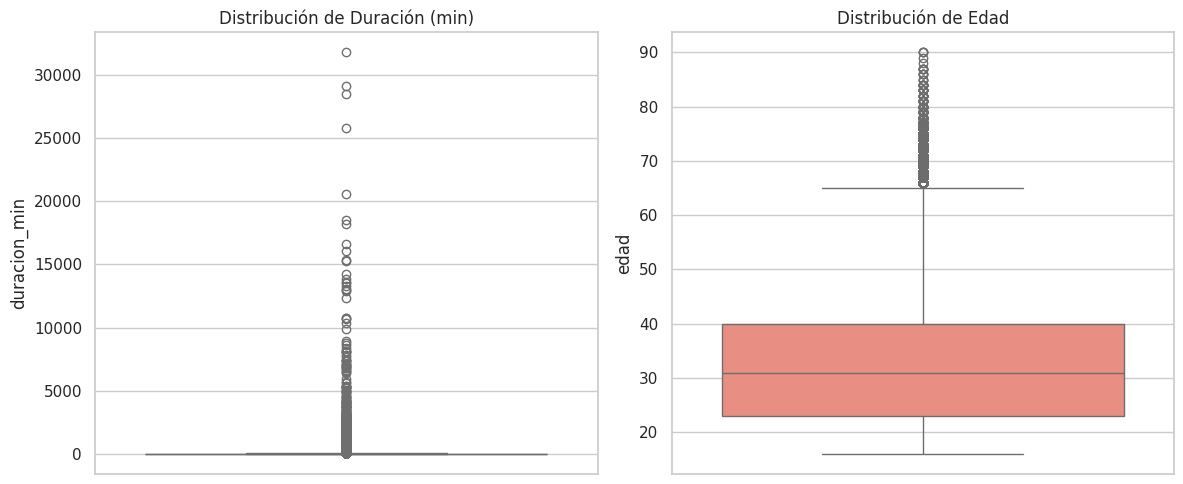

--- Análisis de Outliers: duracion_min ---
🔹 Cantidad de outliers: 188779
🔹 Porcentaje del dataset: 5.98%
--- Análisis de Outliers: edad ---
🔹 Cantidad de outliers: 7274
🔹 Porcentaje del dataset: 0.23%


In [26]:
# Diagnostico de Outliers

# Estadística rápida para ver Min y Max
print("📊 Resumen estadístico de variables críticas:")
display(df_recorridos[['duracion_min', 'edad']].describe())

# Visualización para detectar Outliers
plt.figure(figsize=(12, 5))

# Boxplot Duración
plt.subplot(1, 2, 1)
sns.boxplot(data=df_recorridos, y='duracion_min', color='skyblue')
plt.title('Distribución de Duración (min)')

# Boxplot Edad
plt.subplot(1, 2, 2)
sns.boxplot(data=df_recorridos, y='edad', color='salmon')
plt.title('Distribución de Edad')

plt.tight_layout()
plt.show()

# Medir el impacto de Outliers en el total de datos
def calcular_impacto_outliers(df, columna):
    # Calcular los límites (IQR)
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]

    # Calcular porcentajes
    total_filas = len(df)
    cant_outliers = len(outliers)
    porcentaje = (cant_outliers / total_filas) * 100

    print(f"--- Análisis de Outliers: {columna} ---")
    print(f"🔹 Cantidad de outliers: {cant_outliers}")
    print(f"🔹 Porcentaje del dataset: {porcentaje:.2f}%")

    return porcentaje

# Ejecutar para ver el porcentaje de outliers
porc_duracion = calcular_impacto_outliers(df_recorridos, 'duracion_min')
porc_edad = calcular_impacto_outliers(df_recorridos, 'edad')



Analizando los resultados podemos decir que:

### 1. Análisis de Duración (`duracion_min`)

* **Mínimo (2.0 min):** Es un valor sano.
* **Máximo (180.0 min):** 3 horas. En el contexto de EcoBici, un viaje de 3 horas es inusual pero físicamente posible (alguien paseando un domingo). Sin embargo, el **Boxplot** muestra una "mancha" densa de puntos por encima de los 50 minutos. Para que el modelo de regresión no se sesgue por viajes recreativos largos, podríamos aplicar el **filtro del Rango Intercuartílico (IQR)** o un tope de negocio (ej. 60 min).
* **6% de Outiers:** Un volumen que no se puede ignorar tan a la ligera. Estos outliers podrían ser usuarios que usan la bici para recreación larga o gente que se olvidó de anclarla correctamente. Por lo que, en lugar de usar el límite estricto del IQR (que suele ser muy bajo), se establece un límite de no más de 2 horas o 120 min. Esto limpia los errores groseros pero mantiene los viajes largos reales.



### 2. Análisis de Edad (`edad`)

* **Mínimo (16 años):** Cumple con el límite legal del servicio.
* **Máximo (90 años):** Aunque hay personas de 90 años muy vitales, el gráfico muestra que después de los **65 años** (aprox), los puntos empiezan a quedar aislados.Estos son valores atípicos "reales" (existen), *pero si son muy pocos, pueden dificultar que LOS algoritmos encuentren patrones claros*.
* **0.23% de Outliers:** Estos 7.274 registros son casos aislados que **no representan la tendencia de tus usuarios.** Al ser menos del 1%, borrarlos no afecta la representatividad del dataset.

In [27]:
# Filtrar outliers

# 'edad': Eliminar los outliers extremos
Q1_e = df_recorridos['edad'].quantile(0.25)
Q3_e = df_recorridos['edad'].quantile(0.75)
IQR_e = Q3_e - Q1_e
lim_sup_e = Q3_e + 1.5 * IQR_e

# Filtrar edad
df_limpio = df_recorridos[df_recorridos['edad'] <= lim_sup_e].copy()

# 'duración_min': Usar un criterio de negocio (90 min)
limite_negocio_duracion = 90
df_limpio = df_limpio[df_limpio['duracion_min'] <= limite_negocio_duracion]

print(f"✅ Dataset consolidado.")
print(f"📊 Registros finales: {df_limpio.shape[0]}")
print(f"📉 Pérdida total de datos: {((len(df_recorridos) - len(df_limpio)) / len(df_recorridos)) * 100:.2f}%")

✅ Dataset consolidado.
📊 Registros finales: 3098558
📉 Pérdida total de datos: 1.82%


📊 Situación Actual: Tratamiento de Valores Atípicos (Outliers)


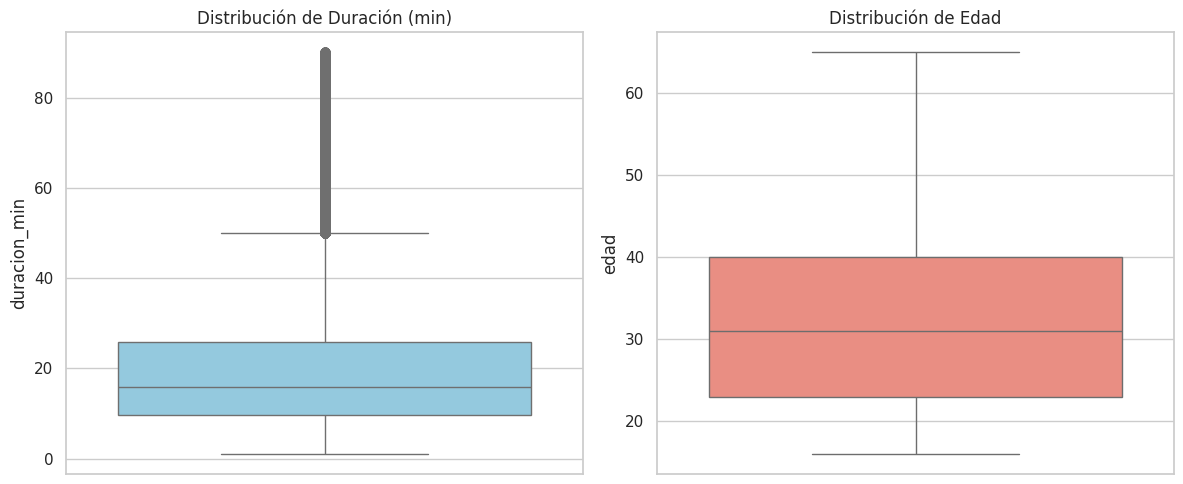

--- Análisis de Outliers: duracion_min ---
🔹 Cantidad de outliers: 151949
🔹 Porcentaje del dataset: 4.90%
--- Análisis de Outliers: edad ---
🔹 Cantidad de outliers: 0
🔹 Porcentaje del dataset: 0.00%


In [28]:
# Outliers: Situación Actual
print(f"📊 Situación Actual: Tratamiento de Valores Atípicos (Outliers)")

# Visualización para detectar Outliers
plt.figure(figsize=(12, 5))

# Boxplot Duración
plt.subplot(1, 2, 1)
sns.boxplot(data=df_limpio, y='duracion_min', color='skyblue')
plt.title('Distribución de Duración (min)')

# Boxplot Edad
plt.subplot(1, 2, 2)
sns.boxplot(data=df_limpio, y='edad', color='salmon')
plt.title('Distribución de Edad')

plt.tight_layout()
plt.show()

# Medir el impacto de estos Outliers en el total de datos- Situación Actual
porc_duracion = calcular_impacto_outliers(df_limpio, 'duracion_min')
porc_edad = calcular_impacto_outliers(df_limpio, 'edad')

#### 📊 Situación Actual: Tratamiento de Valores Atípicos (Outliers)

Tras la fase de limpieza y consolidación del dataset, se realizó un análisis de valores atípicos sobre las variables críticas: `edad` y `duración_min`. El objetivo fue equilibrar la pureza estadística con la realidad del negocio de movilidad urbana.

 1. Edad: Limpieza Estadística Rigurosa

Se aplicó el criterio del **Rango Intercuartílico ($1.5 \times IQR$)**.

* Se eliminó un **0.23%** de los registros.


* Dada la ínfima pérdida de datos, se priorizó la eliminación de ruido (posibles errores de carga o edades biológicamente inconsistentes con el uso de bicicletas públicas), logrando una distribución limpia sin outliers remanentes.



 2. Duración: Criterio de Negocio vs. Criterio Estadístico

A diferencia de la edad, la duración presentó un **5.98%** de outliers bajo la regla del IQR.

* Se optó por una **flexibilidad estratégica**, estableciendo un límite superior de **90 minutos**.


* **Estado Actual:** 4.90% (151.949 registros)** que se sitúan por encima del "bigote" estadístico del boxplot.


*  Eliminar el 6% del dataset basándose solo en el IQR sería una pérdida de información valiosa. Un viaje de 40 o 60 minutos es un comportamiento de usuario real y válido (ej. paseos recreativos). El límite de 90 minutos actúa como un filtro de "sentido común" para descartar viajes fallidos o bicis mal ancladas, sin sacrificar la diversidad del comportamiento del usuario.

In [29]:
# Asignar de df_limpio a df_recorridos
df_recorridos = df_limpio.copy()

## **🔹 4. Definición de Variables de Comportamiento**

### ✔ Dataset final por usuario

El dataset original se enfoca en "viajes individuales", pero nuestro objetivo es predecir el comportamiento del usuario. Por lo tanto, realizaremos una agregación de datos. Se Construye de un dataset **por usuario** con métricas que capturan su patrón de uso histórico.

Crearemos nuevas métricas como recencia (días desde el último viaje) y frecuencia (viajes totales), basándonos en la intuición de que un usuario que no usa el servicio hace tiempo tiene mayor probabilidad de Churn (abandono).


| Variable | Descripción |
|---|---|
| `recencia` | Días desde el último viaje (respecto al máximo del dataset) |
| `frecuencia` | Total de viajes realizados |
| `duracion_media` | Duración promedio de los viajes (min) |
| `duracion_total` | Duración total acumulada (min) |
| `variabilidad_duracion` | Desviación estándar de duración (min) |
| `dias_activo` | Días distintos con al menos un viaje |
| `intervalo_medio` | Promedio de días entre viajes consecutivos |
| `pct_finde` | % de viajes en fin de semana |
| `hora_favorita` | Hora del día con más viajes |

In [30]:
# Fecha de referencia: último día del dataset
fecha_ref = df_recorridos['fecha_origen_recorrido'].max()
print(f"📅 Fecha de referencia: {fecha_ref.date()}")

# Agregaciones por usuario
agg = df_recorridos.groupby('id_usuario').agg(
    ultimo_viaje   = ('fecha_origen_recorrido', 'max'),
    primer_viaje   = ('fecha_origen_recorrido', 'min'),
    frecuencia     = ('Id_recorrido',           'count'),
    duracion_media = ('duracion_min',            'mean'),
    duracion_total = ('duracion_min',            'sum'),
    variabilidad_duracion = ('duracion_min',     'std'),
    dias_activo    = ('fecha',                   'nunique'),
    pct_finde      = ('dia_semana', lambda x: (x >= 5).mean() * 100),
    hora_favorita  = ('hora', lambda x: x.mode()[0]),
    edad           = ('edad',  'last'),
    genero         = ('género','last'),
).reset_index()

# Recencia (días desde último viaje)
agg['recencia'] = (fecha_ref - agg['ultimo_viaje']).dt.days

# Intervalo medio entre viajes (días)
agg['antiguedad_dias'] = (agg['ultimo_viaje'] - agg['primer_viaje']).dt.days
agg['intervalo_medio'] = np.where(
    agg['frecuencia'] > 1,
    agg['antiguedad_dias'] / (agg['frecuencia'] - 1),
    agg['antiguedad_dias']
)

# Rellenar NaN para usuarios con 1 solo viaje
agg['variabilidad_duracion'] = agg['variabilidad_duracion'].fillna(0)

print(f"✅ Dataset de usuarios construido: {agg.shape}")
agg.head(3)

📅 Fecha de referencia: 2025-12-31
✅ Dataset de usuarios construido: (274739, 15)


,id_usuario,ultimo_viaje,primer_viaje,frecuencia,duracion_media,duracion_total,variabilidad_duracion,dias_activo,pct_finde,hora_favorita,edad,genero,recencia,antiguedad_dias,intervalo_medio
0,1000011BAEcobici,2025-12-03 18:48:12,2025-10-28 19:55:17,3,17.900000,53.700000,7.918035,3,0.000000,17,22,FEMALE,28,35,17.5
1,1000020BAEcobici,2025-07-02 12:51:28,2025-05-23 17:55:56,3,18.144444,54.433333,4.837852,2,0.000000,12,24,MALE,182,39,19.5
2,1000029BAEcobici,2025-07-30 18:19:14,2025-07-12 13:32:29,11,35.340909,388.750000,14.704033,9,18.181818,18,36,MALE,154,18,1.8


##**🔹 5. Definición de Variables de Target**

In [31]:
# Separación temporal (Pasado vs Futuro)
fecha_max = df_recorridos['fecha_origen_recorrido'].max()
fecha_corte = fecha_max - pd.Timedelta(days=30)

In [32]:
# Filtrar el pasado para las Features (X)
pasado = df_recorridos[df_recorridos['fecha_origen_recorrido'] < fecha_corte]

# Crear las variables de comportamiento
agg = pasado.groupby('id_usuario').agg(
    viajes_totales_hist=('Id_recorrido', 'count'),
    promedio_duracion_hist=('duracion_min', 'mean'),
    estaciones_unicas=('id_estacion_origen', 'nunique'),
    edad=('edad', 'first'),
    genero=('género', 'first'),
    # Variable de recencia pero calculada al momento del corte
    ultima_fecha_pasado=('fecha_origen_recorrido', 'max')
).reset_index()

# Calcular recencia histórica
#(qué tan inactivo estaba el usuario hasta el día del corte)
agg['recencia_hist'] = (fecha_corte - agg['ultima_fecha_pasado']).dt.days

# Definir el TARGET (y)
# Qué pasó en el "Presente" (últimos 30 días del dataset)
presente = df_recorridos[df_recorridos['fecha_origen_recorrido'] >= fecha_corte]

### ✔ Churn

La consigna original define churn como ausencia total de recorridos durante **60 días continuos**. Para este proyecto se adoptó una simplificación: se considera churn la **inactividad en los últimos 30 días** del dataset. Esta decisión se justifica por dos razones:
- Maximiza la cantidad de usuarios evaluables en el período de prueba, dado el horizonte temporal del dataset (1 año).
- Es coherente con el comportamiento observado del sistema, donde la frecuencia mediana de uso es de ~3 viajes por período.

In [33]:
# Target 1: Churn
usuarios_activos_futuro = presente['id_usuario'].unique()
# Si está activo es 0, si NO está activo es 1
esta_activo = agg['id_usuario'].isin(usuarios_activos_futuro)
agg['churn'] = (~esta_activo).astype(int)

### ✔ Demanda

In [34]:
# Target 2: Demanda
viajes_30d = presente.groupby('id_usuario').size().reset_index(name='viajes_30d')
agg = agg.merge(viajes_30d, on='id_usuario', how='left')
agg['viajes_30d'] = agg['viajes_30d'].fillna(0).astype(int)

📊 Tasa de churn real (basada en inactividad del último mes): 82.24%
📊 Promedio de viajes futuros: 0.87


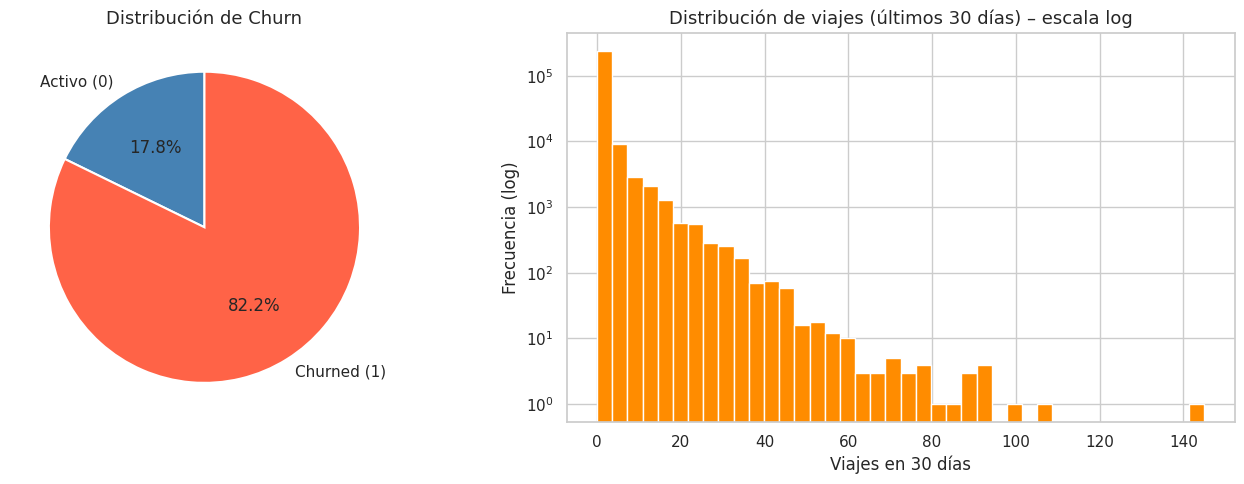

In [35]:
# Visualización
print(f"📊 Tasa de churn real (basada en inactividad del último mes): {agg['churn'].mean()*100:.2f}%")
print(f"📊 Promedio de viajes futuros: {agg['viajes_30d'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn
churn_labels = ['Activo (0)', 'Churned (1)']
axes[0].pie(
    agg['churn'].value_counts().sort_index(),
    labels=churn_labels, autopct='%1.1f%%',
    colors=['steelblue','tomato'], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Distribución de Churn', fontsize=13)

# Demanda futura
axes[1].hist(agg['viajes_30d'], bins=40, color='darkorange', edgecolor='white', log=True)
axes[1].set_title('Distribución de viajes (últimos 30 días) – escala log', fontsize=13)
axes[1].set_xlabel('Viajes en 30 días')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()


## **🔹 6. Análisis de Correlaciones y Predictores**


In [36]:
# Variables numéricas disponibles
features_corr = [
    'viajes_totales_hist',
    'promedio_duracion_hist',
    'estaciones_unicas',
    'recencia_hist',
    'edad',
    'churn',
    'viajes_30d'
]

# Verificar que todas existan
faltantes = [c for c in features_corr if c not in agg.columns]
if faltantes:
    print(f"⚠️ Columnas faltantes: {faltantes}")
else:
    print("✅ Todas las variables están disponibles.")
    print(f"   Dataset: {agg.shape[0]:,} usuarios × {agg.shape[1]} columnas")


✅ Todas las variables están disponibles.
   Dataset: 258,850 usuarios × 10 columnas


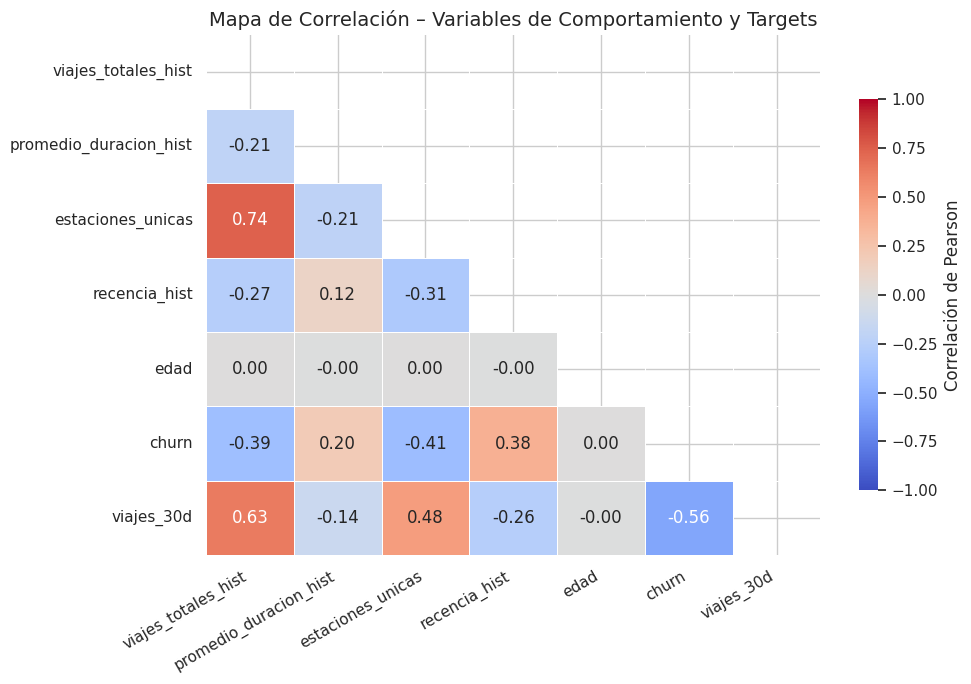

In [37]:
# Mapa de correlación general
corr = agg[features_corr].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Correlación de Pearson'}
)

plt.title('Mapa de Correlación – Variables de Comportamiento y Targets', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Se observa una correlación positiva moderada entre la `edad` y la `duracion_promedio`, sugiriendo que los usuarios mayores tienden a realizar recorridos más extensos o pausados. Por otro lado, la `recencia` muestra una correlación inversa con el `target`, lo que valida la hipótesis inicial de que la inactividad reciente es un predictor clave para el modelo.

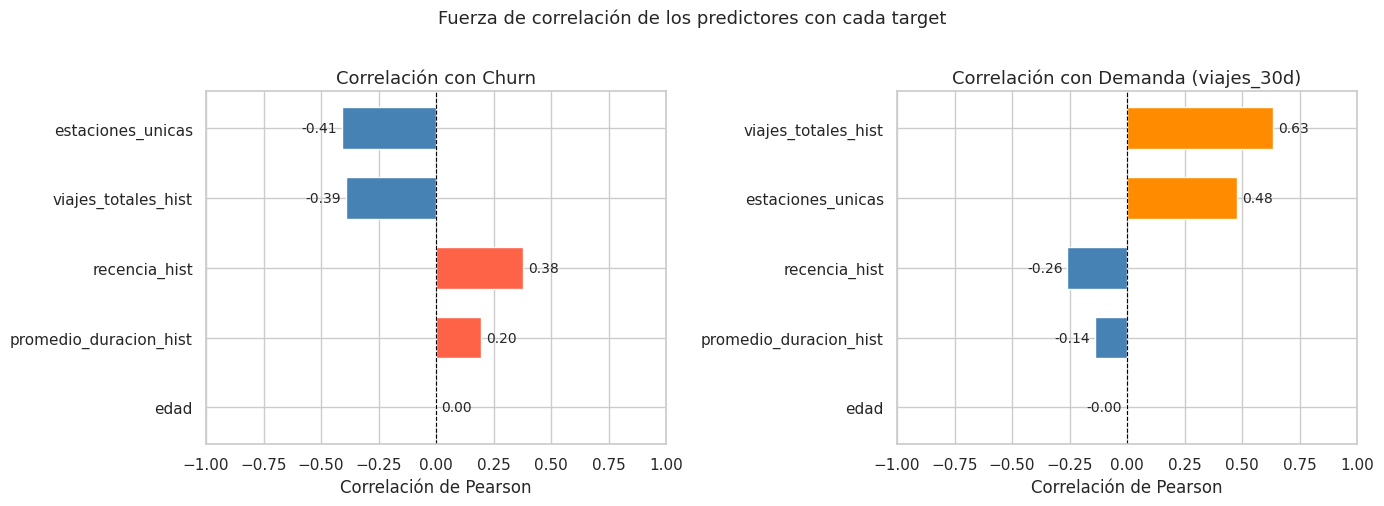

In [38]:
# Correlación con cada target por separado
features_predictoras = [
    'viajes_totales_hist',
    'promedio_duracion_hist',
    'estaciones_unicas',
    'recencia_hist',
    'edad'
]

corr_churn   = corr['churn'][features_predictoras].sort_values(key=abs, ascending=True)
corr_demanda = corr['viajes_30d'][features_predictoras].sort_values(key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn
colores_c = ['tomato' if v > 0 else 'steelblue' for v in corr_churn]
axes[0].barh(corr_churn.index, corr_churn.values, color=colores_c, edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Correlación con Churn', fontsize=13)
axes[0].set_xlabel('Correlación de Pearson')
axes[0].set_xlim(-1, 1)
for i, v in enumerate(corr_churn.values):
    axes[0].text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=10)

# Demanda
colores_d = ['darkorange' if v > 0 else 'steelblue' for v in corr_demanda]
axes[1].barh(corr_demanda.index, corr_demanda.values, color=colores_d, edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlación con Demanda (viajes_30d)', fontsize=13)
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_xlim(-1, 1)
for i, v in enumerate(corr_demanda.values):
    axes[1].text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.suptitle('Fuerza de correlación de los predictores con cada target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

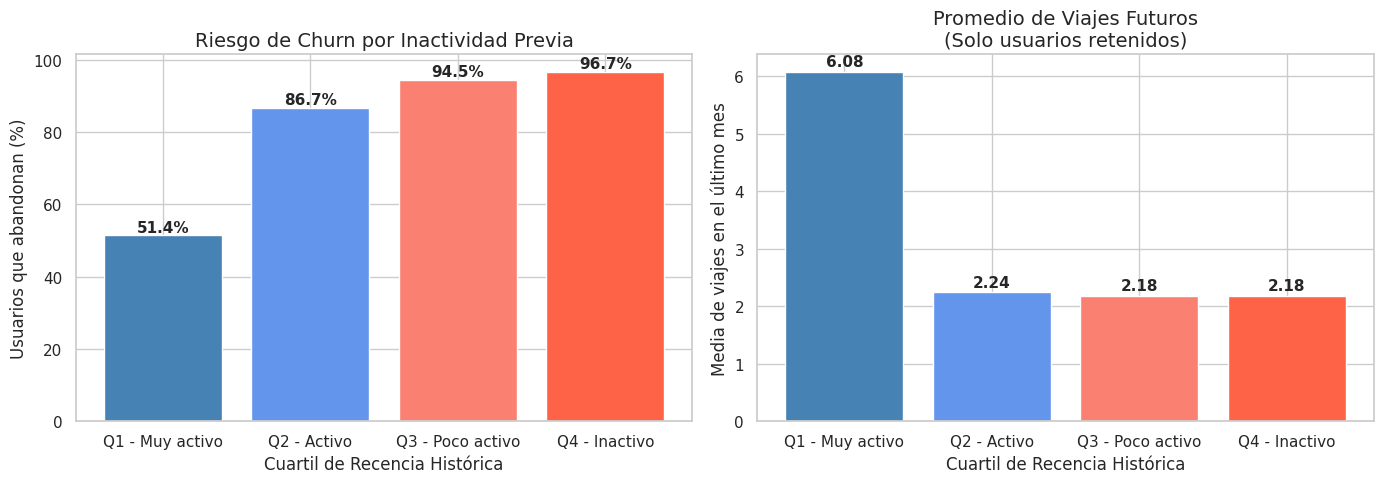

In [39]:
# Análisis adicional: Churn según recencia histórica
# Dividir recencia en cuartiles para visualizar la tasa de churn por nivel de inactividad

agg['recencia_cuartil'] = pd.qcut(agg['recencia_hist'], q=4,
                                   labels=['Q1 - Muy activo', 'Q2 - Activo',
                                           'Q3 - Poco activo', 'Q4 - Inactivo'])

# Preparar los datos para los dos gráficos
# Gráfico Izquierdo: Probabilidad de pérdida (Churn)
churn_por_recencia = agg.groupby('recencia_cuartil', observed=True)['churn'].mean() * 100

# Gráfico Derecho: Valor del usuario activo
# Usuarios con viajes_30d > 0
activos_futuros = agg[agg['viajes_30d'] > 0].copy()
viajes_media_activos = activos_futuros.groupby('recencia_cuartil', observed=True)['viajes_30d'].mean()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por cuartil de recencia
colores_q = ['steelblue', 'cornflowerblue', 'salmon', 'tomato']
axes[0].bar(churn_por_recencia.index, churn_por_recencia.values,
            color=colores_q, edgecolor='white')
axes[0].set_title('Riesgo de Churn por Inactividad Previa', fontsize=14, )
axes[0].set_xlabel('Cuartil de Recencia Histórica')
axes[0].set_ylabel('Usuarios que abandonan (%)')
for i, v in enumerate(churn_por_recencia.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Media de Viajes (Solo USuarios Activos)
axes[1].bar(viajes_media_activos.index, viajes_media_activos.values,
            color=colores_q, edgecolor='white')
axes[1].set_title('Promedio de Viajes Futuros\n(Solo usuarios retenidos)', fontsize=14, )
axes[1].set_xlabel('Cuartil de Recencia Histórica')
axes[1].set_ylabel('Media de viajes en el último mes')
for i, v in enumerate(viajes_media_activos.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Limpiar columna auxiliar
agg.drop(columns='recencia_cuartil', inplace=True)

#### 📊 Interpretación de Correlaciones y Segmentación


**Con Churn:**

* **`recencia_hist` como Predictor Crítico:** Se confirma como la variable con mayor poder predictivo. La probabilidad de abandono no es lineal: salta del **51.4%** en usuarios activos (**Q1**) a un masivo **96.7%** en inactivos (**Q4**).


* **`viajes_totales_hist` y Fidelización:** La correlación negativa es robusta; una base sólida de viajes históricos actúa como un "escudo" contra el abandono.


* **`estaciones_unicas` y Engagement:** El uso de diversas estaciones indica un usuario integrado al sistema, lo que reduce significativamente el riesgo de Churn.



**Con Demanda (`viajes_30d`):**

* **El Efecto del "Super-User":** Gracias al análisis de media condicional, observamos que el comportamiento pasado no solo predice la actividad, sino que define el **valor**. Un usuario retenido del **Q1** promedia **6.08 viajes**, triplicando la demanda de cualquier otro segmento retenido (~2.2 viajes).


* **Indiferencia en la Inactividad:** Para los usuarios que deciden permanecer (viajes > 0), el nivel de inactividad previa (Q2 a Q4) tiene un impacto marginal en la cantidad de viajes futuros, estabilizándose en una media baja.


* **Redundancia de Variables:** `viajes_totales_hist` y `estaciones_unicas` muestran una alta colinealidad, sugiriendo que ambas capturan la misma esencia del compromiso del usuario.



> La inactividad histórica (`recencia_hist`) es el "filtro" que decide quién se queda, pero la intensidad histórica (`viajes_totales`) es la que decide cuánto vale ese usuario para el negocio. Debido a la alta correlación entre variables de frecuencia, evaluaremos la selección de características para evitar redundancias que afecten el funcionamiento de los modelos.
>
>



## **🔹 7. Preparación para el Modelo**

### ⚙️ 7.1.  Procesamiento de Datos

In [40]:
# Estado del dataset antes del procesamiento
print("📋 Columnas disponibles en 'agg':")
print(agg.dtypes.to_string())
print(f"\n📐 Shape: {agg.shape}")
print(f"🔍 Nulos restantes:\n{agg.isnull().sum()[agg.isnull().sum() > 0].to_string()}")

📋 Columnas disponibles en 'agg':
id_usuario                        object
viajes_totales_hist                int64
promedio_duracion_hist           float64
estaciones_unicas                  int64
edad                               int64
genero                            object
ultima_fecha_pasado       datetime64[ns]
recencia_hist                      int64
churn                              int64
viajes_30d                         int64

📐 Shape: (258850, 10)
🔍 Nulos restantes:
Series([], )


>Esta imputación se realiza con fines exploratorios (para construir el dataset 'agg').
La imputación DEFINITIVA y libre de data leakage se aplica post-split en la sección 7.3,
usando exclusivamente estadísticas calculadas sobre el conjunto de entrenamiento (X_train).
>
>

In [41]:
# Imputación de nulos residuales

# 'edad': imputar con la mediana por género
agg['edad'] = agg.groupby('genero')['edad'].transform(lambda x: x.fillna(x.median()))

# Si aún quedan NaN, usar mediana global
agg['edad'] = agg['edad'].fillna(agg['edad'].median())

# 'genero': imputar con 'OTHER'
agg['genero'] = agg['genero'].fillna('OTHER')

# 'promedio_duracion_hist': imputar con mediana global
agg['promedio_duracion_hist'] = agg['promedio_duracion_hist'].fillna(agg['promedio_duracion_hist'].median())

print(f"✅ Nulos tras imputación: {agg.isnull().sum().sum()}")

✅ Nulos tras imputación: 0


### 🎯 7.2. Selección de variables

Se excluyen:
- 'id_usuario'           → identificador, no es un predictor
- 'ultima_fecha_pasado'  → fecha cruda, ya está capturada en 'recencia_hist'
- 'genero'               → reemplazada por 'genero_enc'
- 'churn' y 'viajes_30d' → son los targets

Se incluyen:
- 'viajes_totales_hist'     → Frecuencia histórica de uso
- 'promedio_duracion_hist'  → Duración promedio de los viajes
- 'estaciones_unicas'       → Diversidad de uso del sistema
- 'recencia_hist'           → Días de inactividad antes del corte
- 'edad'                    → Perfil demográfico
- 'genero'                  → La mantenemos para el split y luego aplicamos One-Hot

In [42]:
# Features finales para el modelo

FEATURES = [
    'viajes_totales_hist',     # Frecuencia histórica de uso
    'promedio_duracion_hist',  # Duración promedio de los viajes
    'estaciones_unicas',       # Diversidad de uso del sistema
    'recencia_hist',           # Días de inactividad antes del corte
    'edad',                    # Perfil demográfico
    'genero',              # La mantenemos para el split y luego aplicamos One-Hot
]

TARGET_CHURN   = 'churn'
TARGET_DEMANDA = 'viajes_30d'

print(f"✅ Features seleccionadas ({len(FEATURES)}):")
for f in FEATURES:
    print(f"   • {f}")

print(f"\n🎯 Targets definidos:")
print(f"   • {TARGET_CHURN}   → clasificación binaria")
print(f"   • {TARGET_DEMANDA} → regresión")

✅ Features seleccionadas (6):
   • viajes_totales_hist
   • promedio_duracion_hist
   • estaciones_unicas
   • recencia_hist
   • edad
   • genero

🎯 Targets definidos:
   • churn   → clasificación binaria
   • viajes_30d → regresión


In [43]:
# Dataset final para modelado

df_modelo = agg[FEATURES + [TARGET_CHURN, TARGET_DEMANDA]].copy()
df_modelo.dropna(inplace=True)

print(f"📐 Shape del dataset de modelado: {df_modelo.shape}")
print(f"   → {df_modelo.shape[0]:,} usuarios listos para entrenar")
df_modelo.describe().T

📐 Shape del dataset de modelado: (258850, 8)
   → 258,850 usuarios listos para entrenar


,count,mean,std,min,25%,50%,75%,max
viajes_totales_hist,258850.0,10.958648,27.668929,1.000000,1.000000,3.000000,8.000000,1054.0
promedio_duracion_hist,258850.0,28.173405,15.988096,1.016667,16.455556,24.691667,36.383333,90.0
estaciones_unicas,258850.0,4.007885,5.307257,1.000000,1.000000,2.000000,5.000000,134.0
recencia_hist,258850.0,126.609793,106.912883,0.000000,27.000000,97.000000,222.000000,334.0
edad,258850.0,31.949202,10.865353,16.000000,23.000000,31.000000,40.000000,65.0
churn,258850.0,0.822376,0.382197,0.000000,1.000000,1.000000,1.000000,1.0
viajes_30d,258850.0,0.866896,3.358313,0.000000,0.000000,0.000000,0.000000,145.0


### 📂 7.3. División del dataset: Train / Test Split



In [44]:
# Matrices X e y
X = df_modelo[FEATURES]
y_churn   = df_modelo[TARGET_CHURN]
y_demanda = df_modelo[TARGET_DEMANDA]

print(f"X shape : {X.shape}")
print(f"y_churn  – clase 0: {(y_churn==0).sum():,}  |  clase 1: {(y_churn==1).sum():,}")
print(f"y_demanda – media : {y_demanda.mean():.2f}  | mediana: {y_demanda.median():.0f}")


X shape : (258850, 6)
y_churn  – clase 0: 45,978  |  clase 1: 212,872
y_demanda – media : 0.87  | mediana: 0


In [45]:
# plit 80/20 estratificado por Churn para evitar Data Leakage

X_train, X_test, y_churn_train, y_churn_test = train_test_split(
    X, y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

# Usar los mismos índices para el target de demanda
y_demanda_train = y_demanda.loc[X_train.index]
y_demanda_test  = y_demanda.loc[X_test.index]

print("📊 Dimensiones del split:")
print(f"   X_train : {X_train.shape}  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   X_test  : {X_test.shape}   ({X_test.shape[0]/len(X)*100:.0f}%)")


📊 Dimensiones del split:
   X_train : (207080, 6)  (80%)
   X_test  : (51770, 6)   (20%)


In [46]:
# Imputación de nulos (Post-Split)

# 'genero': imputar con 'OTHER'
X_train['genero'] = X_train['genero'].fillna('OTHER')
X_test['genero'] = X_test['genero'].fillna('OTHER')

# 'edad': imputar con la mediana del TRAIN para evitar leakage
# Calcular medianas por género basadas solo en X_train
medianas_edad_train = X_train.groupby('genero')['edad'].median()

def aplicar_imputacion_edad(df, medianas):
    df['edad'] = df.apply(
        lambda x: medianas[x['genero']] if pd.isna(x['edad']) else x['edad'], axis=1
    )
    return df['edad'].fillna(X_train['edad'].median())

X_train['edad'] = aplicar_imputacion_edad(X_train, medianas_edad_train)
X_test['edad'] = aplicar_imputacion_edad(X_test, medianas_edad_train)

# 'promedio_duracion_hist': imputar con mediana de TRAIN
mediana_dur_train = X_train['promedio_duracion_hist'].median()
X_train['promedio_duracion_hist'] = X_train['promedio_duracion_hist'].fillna(mediana_dur_train)
X_test['promedio_duracion_hist'] = X_test['promedio_duracion_hist'].fillna(mediana_dur_train)

print(f"✅ Nulos tras imputación: {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}")

✅ Nulos tras imputación: 0


In [47]:
# Codificación de 'genero' con One-Hot Encoding
# Evitar el orden falso del LabelEncoder
X_train = pd.get_dummies(X_train, columns=['genero'], prefix='gen', drop_first=True)
X_test = pd.get_dummies(X_test, columns=['genero'], prefix='gen', drop_first=True)

# Asegurar que ambos tengan las mismas columnas (alineación)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Actualizar lista de FEATURES finales
FEATURES_FINALES = X_train.columns.tolist()

print(f"✅ Procesamiento completado:")
print(f"   • Features finales: {len(FEATURES_FINALES)}")
print(f"   • One-Hot aplicado: {X_train.columns[X_train.columns.str.startswith('gen')].tolist()}")
print(f"   • Nulos residuales: {X_train.isnull().sum().sum()}")

✅ Procesamiento completado:
   • Features finales: 7
   • One-Hot aplicado: ['gen_MALE', 'gen_OTHER']
   • Nulos residuales: 0


Dado que utilizaremos algoritmos sensibles a la distancia (como KNN o modelos lineales), aplicaremos StandardScaler. Esto es fundamental porque variables como `edad` (0-100) y `duracion` (0-240) tienen escalas muy diferentes; sin el escalado, el modelo le daría una importancia artificialmente mayor a la duración solo por su magnitud numérica.

In [48]:
# Escalado con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURES_FINALES,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURES_FINALES,
    index=X_test.index
)

print("✅ Escalado aplicado (StandardScaler):")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")

✅ Escalado aplicado (StandardScaler):
   X_train_scaled shape: (207080, 7)


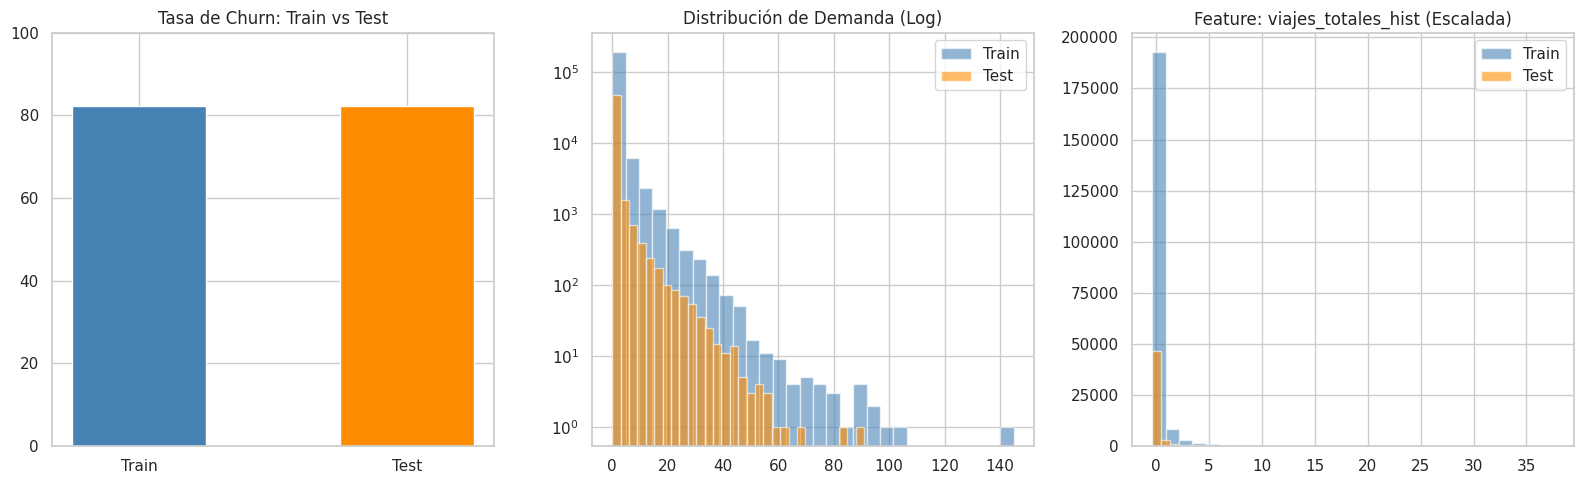

In [49]:
# Visualización de la División
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de Churn
splits = ['Train', 'Test']
churn_vals = [y_churn_train.mean()*100, y_churn_test.mean()*100]
axes[0].bar(splits, churn_vals, color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
axes[0].set_title('Tasa de Churn: Train vs Test', fontsize=12)
axes[0].set_ylim(0, 100)

# Distribución de Demanda
axes[1].hist(y_demanda_train, bins=30, alpha=0.6, color='steelblue', label='Train', log=True)
axes[1].hist(y_demanda_test,  bins=30, alpha=0.6, color='darkorange', label='Test',  log=True)
axes[1].set_title('Distribución de Demanda (Log)', fontsize=12)
axes[1].legend()

# Feature escalada
axes[2].hist(X_train_scaled['viajes_totales_hist'], bins=30, alpha=0.6, color='steelblue', label='Train')
axes[2].hist(X_test_scaled['viajes_totales_hist'],  bins=30, alpha=0.6, color='darkorange', label='Test')
axes[2].set_title('Feature: viajes_totales_hist (Escalada)', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()

In [50]:
# Resumen final: datos listos para modelado
print("=" * 58)
print("   RESUMEN FINAL – PRE-ENTREGA COMPLETADA")
print("=" * 58)
print()
print("  📦 DATASETS LISTOS PARA MODELADO:")
print(f"     X_train_scaled  : {X_train_scaled.shape}")
print(f"     X_test_scaled   : {X_test_scaled.shape}")
print()
print("  🎯 TARGETS:")
print(f"     y_churn_train   : {y_churn_train.shape}  | churn: {y_churn_train.mean()*100:.1f}%")
print(f"     y_churn_test    : {y_churn_test.shape}   | churn: {y_churn_test.mean()*100:.1f}%")
print(f"     y_demanda_train : {y_demanda_train.shape}  | media: {y_demanda_train.mean():.2f}")
print(f"     y_demanda_test  : {y_demanda_test.shape}   | media: {y_demanda_test.mean():.2f}")
print()
print("  🔧 FEATURES SELECCIONADAS:")
for f in FEATURES_FINALES:
    print(f"     • {f}")
print()
print("  🚀 PRÓXIMOS PASOS (Entrega Final):")
print("     Clasificación Churn → Logistic Regression / KNN / Random Forest")
print("     Regresión Demanda   → Linear Regression / Ridge / Gradient Boosting")
print("=" * 58)

   RESUMEN FINAL – PRE-ENTREGA COMPLETADA

  📦 DATASETS LISTOS PARA MODELADO:
     X_train_scaled  : (207080, 7)
     X_test_scaled   : (51770, 7)

  🎯 TARGETS:
     y_churn_train   : (207080,)  | churn: 82.2%
     y_churn_test    : (51770,)   | churn: 82.2%
     y_demanda_train : (207080,)  | media: 0.87
     y_demanda_test  : (51770,)   | media: 0.87

  🔧 FEATURES SELECCIONADAS:
     • viajes_totales_hist
     • promedio_duracion_hist
     • estaciones_unicas
     • recencia_hist
     • edad
     • gen_MALE
     • gen_OTHER

  🚀 PRÓXIMOS PASOS (Entrega Final):
     Clasificación Churn → Logistic Regression / KNN / Random Forest
     Regresión Demanda   → Linear Regression / Ridge / Gradient Boosting


Con los datos limpios, las variables transformadas y el dataset dividido en entrenamiento y prueba, la etapa de preprocesamiento ha finalizado. El dataset resultante cuenta con **7 variables listas** para alimentar el modelo. En la siguiente fase, compararemos el desempeño de Random Forest y Regresión Logística para determinar cuál ofrece un mejor equilibrio entre precisión y recall.

---